# Import and Download the Data


In [1]:
!pip install gdown

In [2]:
import gdown
import pandas as pd
import numpy as np
from pathlib import Path
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import learning_curve


In [3]:
# drive.mount('/content/drive')
# DATA_DIR = Path("/content/drive/MyDrive/ML-MP1-rawdata")

In [4]:
file_id = "12nQWBD0AFbkaZbB7QnN21UYMrpZqcbGG"
url = f"https://drive.google.com/uc?id={file_id}"
output = "ML-MP1-rawdata.zip"

gdown.download(url, output, quiet=False)

!unzip -q ML-MP1-rawdata.zip -d ./ML-MP1-rawdata


Downloading...
From (original): https://drive.google.com/uc?id=12nQWBD0AFbkaZbB7QnN21UYMrpZqcbGG
From (redirected): https://drive.google.com/uc?id=12nQWBD0AFbkaZbB7QnN21UYMrpZqcbGG&confirm=t&uuid=16543f54-1fcb-4701-9ad2-b207b4757ab0
To: /content/ML-MP1-rawdata.zip
100%|██████████| 287M/287M [00:08<00:00, 32.2MB/s]


In [5]:
DATA_DIR=Path("./ML-MP1-rawdata")

#Load the data

## read csv files

In [23]:
def read_sensor_csv(path):
    return pd.read_csv(
        path,
        usecols=[0, 1],
        header=0,
        names=["timestamp", "value"],
        dtype={
            "timestamp": "int64",
            "value": "object"
        }
    )


sensor_data = {}

for csv_file in sorted(DATA_DIR.glob("*.csv")):
    sensor_data[csv_file.stem] = read_sensor_csv(csv_file)

print(f"Loaded {len(sensor_data)} CSV files.")



Loaded 20 CSV files.


## parse latitude and longitude

In [24]:
def parse_lat_lon(val):
    if pd.isna(val):
        return np.nan

    val = str(val).strip()

    try:
        hemi = val[-1].upper()
        num = float(val[:-1])

        degrees = int(num // 100)
        minutes = num % 100

        decimal = degrees + minutes / 60

        if hemi in ["S", "W"]:
            decimal = -decimal

        return decimal

    except Exception:
        return np.nan


In [25]:
sensor_data["latitude"]["value"] = sensor_data["latitude"]["value"].apply(parse_lat_lon)
sensor_data["longitude"]["value"] = sensor_data["longitude"]["value"].apply(parse_lat_lon)


In [26]:
for name, df in sensor_data.items():
    if name not in ["latitude", "longitude"]:
        df["value"] = pd.to_numeric(df["value"], errors="coerce")

## parse the datetime, resample, and combine data into one dataframe

In [27]:
def ticks_to_datetime_safe(ticks):
    ns_since_epoch = (ticks - 621355968000000000) * 100
    return pd.to_datetime(ns_since_epoch, unit="ns")

def prepare_and_resample_sensors(sensor_data: dict, interval: str,):

    resampled = {}
    all_sensor_df_datetime = {}

    for name, df in sensor_data.items():
        df = df.copy()

        df["datetime"] = ticks_to_datetime_safe(df["timestamp"])
        df.drop(columns="timestamp", inplace=True)
        df.set_index("datetime", inplace=True)
        df.sort_index(inplace=True)

        all_sensor_df_datetime[name] = df

        resampled[name] = (
            df["value"]
            .resample(interval)
            .median()
            .astype("float32")
        )
    combined = pd.concat(resampled, axis=1)

    return combined, all_sensor_df_datetime

combined, all_sensor_df_datetime = prepare_and_resample_sensors(sensor_data, interval="1min")


In [28]:
combined["latitude"].isna().sum()

np.int64(52570)

There are gaps in the data. For example around an 8-hour gap here:

In [29]:
all_sensor_df_datetime["latitude"][335030:335036]

,value
datetime,
2010-02-21 22:05:21.508046,61.548872
2010-02-21 22:05:21.613984,61.548872
2010-02-21 22:05:21.618426,61.548872
2010-02-22 05:45:28.140102,61.548795
2010-02-22 05:45:28.247974,61.548795
2010-02-22 05:45:28.262067,61.548795


These gaps are as NaN in our main dataframe now:

In [30]:
combined[9618:10082]

,fuelDensity,fuelTemp,fuelVolumeFlowRate,inclinometer-raw,latitude,level1median,level2median,longitude,longitudinalWaterSpeed,portPitch,portRudder,speedKmh,speedKnots,starboardPitch,starboardRudder,trackDegreeMagnetic,trackDegreeTrue,trueHeading,windAngle,windSpeed
datetime,,,,,,,,,,,,,,,,,,,,
2010-02-21 22:03:00,0.926553,96.063850,0.223433,357.359985,61.549492,16.892794,14.188717,-6.819861,-2.7,1.7400,-8.170,6.6,3.55,-0.0350,8.5115,146.250000,139.250000,310.079987,114.5,6.15
2010-02-21 22:04:00,0.927229,95.696724,0.228389,357.505005,61.549026,16.891521,14.124838,-6.818860,-1.8,1.7255,-8.155,2.7,1.45,1.9675,8.5210,139.850006,132.850006,311.390015,96.0,4.35
2010-02-21 22:05:00,0.927415,95.467224,0.253855,357.410004,61.548885,16.947493,14.145279,-6.818633,-0.6,1.0365,-8.183,1.1,0.60,1.0955,8.5365,148.899994,141.899994,313.200012,93.0,5.10
2010-02-21 22:06:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-02-21 22:07:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2010-02-22 05:42:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-02-22 05:43:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-02-22 05:44:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We drop those large gaps, but try to interploate tiny gaps:

In [31]:
combined = combined.sort_index()
combined = combined.interpolate(limit=3)
combined = combined.dropna()
combined.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 28672 entries, 2010-02-16 12:48:00 to 2010-04-12 22:25:00
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   fuelDensity             28672 non-null  float32
 1   fuelTemp                28672 non-null  float32
 2   fuelVolumeFlowRate      28672 non-null  float32
 3   inclinometer-raw        28672 non-null  float32
 4   latitude                28672 non-null  float32
 5   level1median            28672 non-null  float32
 6   level2median            28672 non-null  float32
 7   longitude               28672 non-null  float32
 8   longitudinalWaterSpeed  28672 non-null  float32
 9   portPitch               28672 non-null  float32
 10  portRudder              28672 non-null  float32
 11  speedKmh                28672 non-null  float32
 12  speedKnots              28672 non-null  float32
 13  starboardPitch          28672 non-null  float32
 14  sta

In [32]:
combined[2770:2776]

,fuelDensity,fuelTemp,fuelVolumeFlowRate,inclinometer-raw,latitude,level1median,level2median,longitude,longitudinalWaterSpeed,portPitch,portRudder,speedKmh,speedKnots,starboardPitch,starboardRudder,trackDegreeMagnetic,trackDegreeTrue,trueHeading,windAngle,windSpeed
datetime,,,,,,,,,,,,,,,,,,,,
2010-02-21 22:06:00,0.927439,95.445084,0.254051,357.409668,61.548885,16.947166,14.146217,-6.818633,-0.597609,1.028373,-8.147210,1.101956,0.601087,1.098871,8.536463,148.609238,141.610870,313.207642,92.860870,5.102826
2010-02-21 22:07:00,0.927464,95.422943,0.254247,357.409302,61.548885,16.946840,14.147157,-6.818632,-0.595217,1.020246,-8.111422,1.103913,0.602174,1.102241,8.536426,148.318466,141.321732,313.215271,92.721741,5.105652
2010-02-21 22:08:00,0.927488,95.400803,0.254442,357.408966,61.548885,16.946514,14.148095,-6.818632,-0.592826,1.012118,-8.075632,1.105870,0.603261,1.105612,8.536389,148.027710,141.032608,313.222900,92.582611,5.108478
2010-02-22 05:45:00,0.938683,85.282730,0.343833,357.250000,61.548878,16.797388,14.577100,-6.818542,0.500000,-2.702000,8.280000,2.000000,1.100000,2.646000,8.519500,15.150000,8.900000,316.709991,29.000000,6.400000
2010-02-22 05:46:00,0.935274,88.152191,0.315234,357.829987,61.549248,16.833006,14.469784,-6.818535,1.200000,3.358000,-0.052000,3.500000,1.900000,3.371000,-0.057000,330.700012,323.899994,321.970001,6.000000,9.050000
2010-02-22 05:47:00,0.935029,89.108299,0.420646,357.809998,61.550514,16.827919,14.235987,-6.819898,6.000000,4.946000,-8.249000,11.100000,6.000000,5.097500,-8.187000,331.500000,327.100006,31.049999,312.000000,12.200000


# Data Analysis and Preprocessing

## Look at the data

In [33]:
combined["EC_tons_per_day"] = (combined["fuelDensity"] * combined["fuelVolumeFlowRate"] * 3600 * 24) / 1000
combined = combined.drop(['fuelDensity', 'fuelVolumeFlowRate'], axis=1)

In [34]:
corr_matrix = combined.corr().abs()
corr_pairs = corr_matrix.unstack()

corr_pairs = corr_pairs[corr_pairs.index.map(lambda x: x[0] != x[1])]
corr_pairs = corr_pairs.sort_values(ascending=False)

high_corr_pairs = corr_pairs[corr_pairs > 0.8].drop_duplicates()
labels = [f"{i[0]}  -  {i[1]}" for i in high_corr_pairs.index]

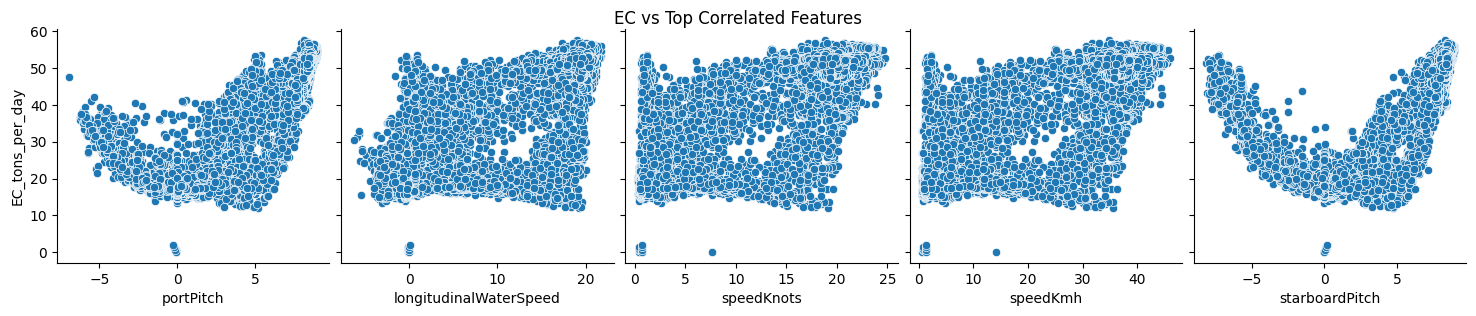

In [35]:
top_corr = corr_matrix["EC_tons_per_day"].abs().sort_values(ascending=False).index[1:6]
sns.pairplot(combined, y_vars=["EC_tons_per_day"], x_vars=top_corr, height=3, aspect=1)
plt.suptitle("EC vs Top Correlated Features", y=1.02)
plt.show()


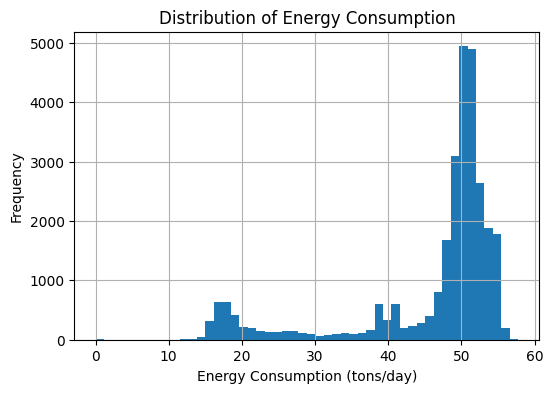

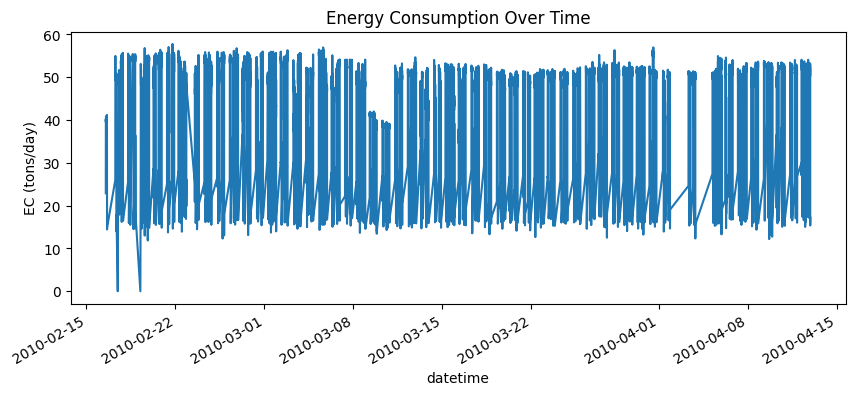

In [36]:
plt.figure(figsize=(6,4))
combined["EC_tons_per_day"].hist(bins=50)
plt.xlabel("Energy Consumption (tons/day)")
plt.ylabel("Frequency")
plt.title("Distribution of Energy Consumption")
plt.show()

combined["EC_tons_per_day"].plot(figsize=(10,4))
plt.ylabel("EC (tons/day)")
plt.title("Energy Consumption Over Time")
plt.show()


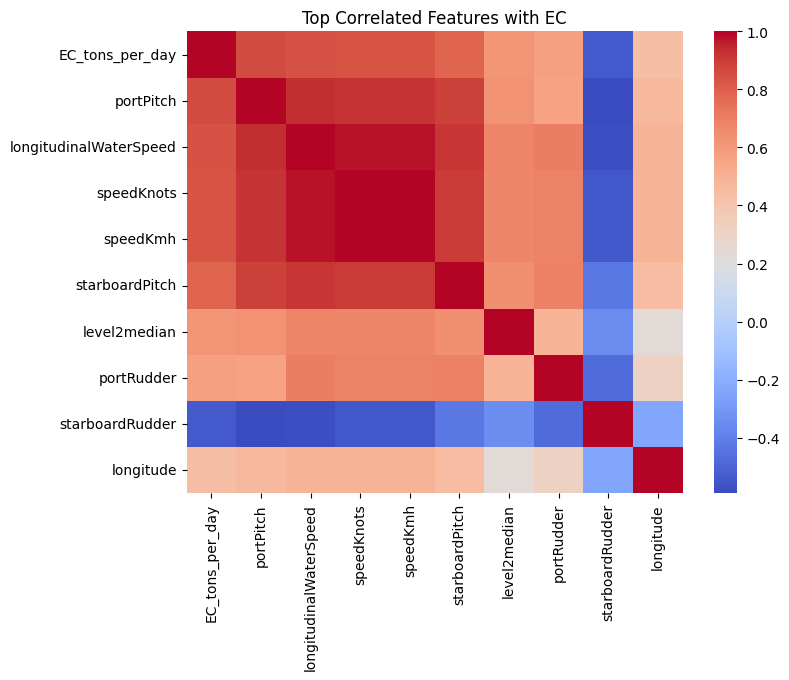

EC_tons_per_day           1.000000
portPitch                 0.858833
longitudinalWaterSpeed    0.840729
speedKnots                0.832881
speedKmh                  0.832855
starboardPitch            0.787130
level2median              0.618199
portRudder                0.571891
starboardRudder          -0.537882
longitude                 0.439992
windSpeed                 0.362109
fuelTemp                  0.256924
trueHeading              -0.181976
level1median             -0.101505
latitude                 -0.087074
windAngle                -0.029979
trackDegreeTrue          -0.006588
inclinometer-raw          0.005828
trackDegreeMagnetic      -0.004553
Name: EC_tons_per_day, dtype: float64


In [37]:
corr = combined.corr()["EC_tons_per_day"].sort_values(key=abs, ascending=False)
plt.figure(figsize=(8,6))
sns.heatmap(
    combined[corr.index[:10]].corr(),
    annot=False,
    cmap="coolwarm"
)
plt.title("Top Correlated Features with EC")
plt.show()
print(corr)

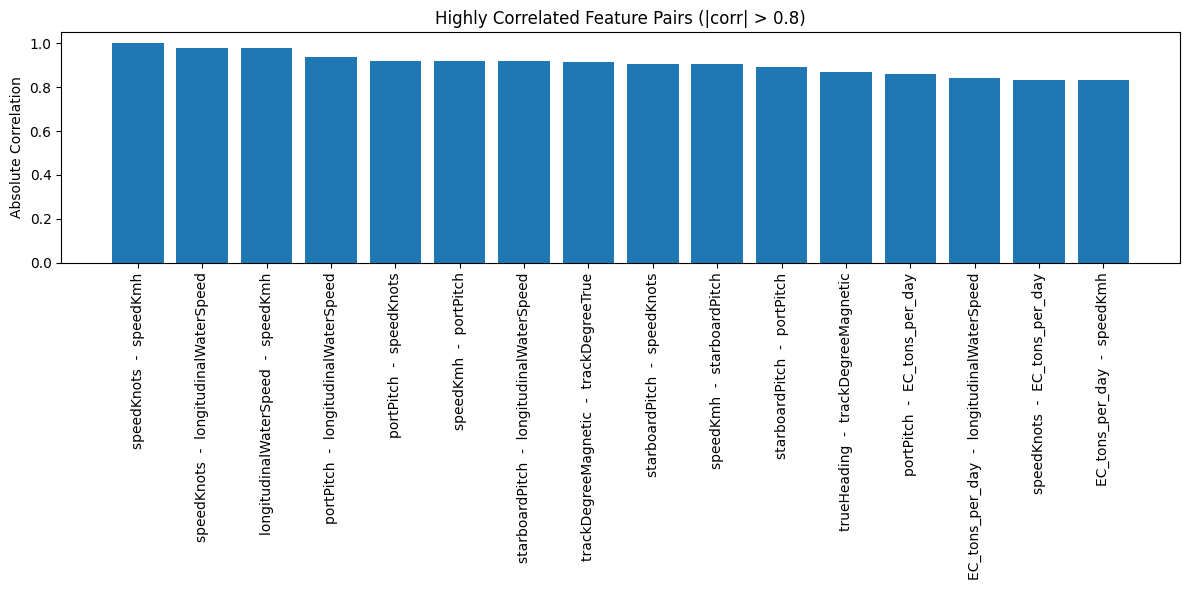

In [38]:
plt.figure(figsize=(12, 6))
plt.bar(range(len(high_corr_pairs)), high_corr_pairs.values)
plt.xticks(range(len(high_corr_pairs)), labels, rotation=90)
plt.ylabel("Absolute Correlation")
plt.title("Highly Correlated Feature Pairs (|corr| > 0.8)")
plt.tight_layout()
plt.show()


## Feature Selection and Engineering

We drop less relevant and correlated features like latitude and longitude, keep one of the highly correlated features (speedKnots and speedKmh), ...
These're the base feature we consider:

selected_raw = [

    "speedKmh",            # propulsion demand
    "windSpeed",           # environmental resistance
    "windAngle",           # directional effect
    "inclinometer-raw",    # trim / attitude
    "trackDegreeTrue",     # heading dynamics
    "level2median",        # load / draft indicator
]

And create some new features from the existing ones:


In [39]:
combined["pitch_mean"] = (combined["portPitch"] + combined["starboardPitch"]) / 2
combined["pitch_diff"] = (combined["portPitch"] - combined["starboardPitch"]).abs()

combined["rudder_activity"] = (combined["portRudder"] - combined["starboardRudder"]).abs()

combined["windAngle_sin"] = np.sin(np.deg2rad(combined["windAngle"]))
combined["windAngle_cos"] = np.cos(np.deg2rad(combined["windAngle"]))

combined["heading_change"] = combined["trackDegreeTrue"].diff().abs()
combined["speed_accel"] = combined["speedKmh"].diff()


In [40]:
final_features = [
    "speedKmh",
    "speed_accel",
    "pitch_mean",
    "pitch_diff",
    "rudder_activity",
    "windSpeed",
    "windAngle_sin",
    "windAngle_cos",
    "heading_change",
    "inclinometer-raw",
    "level2median",
]
final_df = combined[final_features + ["EC_tons_per_day"]].dropna()


In [41]:
final_df

,speedKmh,speed_accel,pitch_mean,pitch_diff,rudder_activity,windSpeed,windAngle_sin,windAngle_cos,heading_change,inclinometer-raw,level2median,EC_tons_per_day
datetime,,,,,,,,,,,,
2010-02-16 12:49:00,10.000000,7.200000,4.85300,1.7160,0.033500,15.900000,-0.754710,-0.656059,22.649994,357.880005,14.163165,35.875187
2010-02-16 12:50:00,21.100000,11.100000,5.47025,1.0395,0.041500,11.800000,-0.737277,-0.675590,9.949997,357.380005,14.206603,30.087780
2010-02-16 12:51:00,23.900000,2.799999,6.39550,1.5040,0.026500,20.450001,-0.983255,0.182235,45.300003,357.429993,13.778615,39.686020
2010-02-16 12:52:00,28.200001,4.300001,6.78800,1.2750,0.034500,24.000000,-0.766045,0.642788,31.099998,357.230011,14.018799,38.382259
2010-02-16 12:53:00,31.100000,2.900000,7.13650,1.2670,0.006000,24.250000,-0.766045,0.642788,1.000000,357.239990,14.132504,39.250988
...,...,...,...,...,...,...,...,...,...,...,...,...
2010-04-12 22:21:00,4.300000,-5.099999,-1.49575,8.9705,8.083000,2.900000,0.484810,0.874620,34.100006,357.260010,14.099286,40.734795
2010-04-12 22:22:00,2.800000,-1.500000,-4.81700,0.1160,0.086500,1.300000,-0.615661,0.788011,110.800003,357.260010,14.244930,28.653606
2010-04-12 22:23:00,5.700000,2.900000,-1.28125,5.5765,16.630001,0.500000,-0.615661,0.788011,23.000000,357.260010,14.136336,20.926720


## Data Split and Scaling

In [42]:
X = final_df[final_features]
y = final_df["EC_tons_per_day"]

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=final_features, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=final_features, index=X_test.index)

print("Training features shape:", X_train_scaled.shape)
print("Testing features shape:", X_test_scaled.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)


Training features shape: (22936, 11)
Testing features shape: (5735, 11)
Training target shape: (22936,)
Testing target shape: (5735,)


# Model Training

## Linear Regression

### Train, Predict, and Evaluate

In [44]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

def evaluate(y_true, y_pred, dataset="Dataset"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{dataset} RMSE: {rmse:.3f}")
    print(f"{dataset} R²: {r2:.3f} \n")

print("Linear Regression Performance:")
evaluate(y_train, y_train_pred_lr, "Train")
evaluate(y_test, y_test_pred_lr, "Test")

coef_df = pd.DataFrame({
    "Feature": final_features,
    "Coefficient": lr_model.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

print("\nLinear Regression Coefficients:")
print(coef_df)


Linear Regression Performance:
Train RMSE: 4.613
Train R²: 0.808 

Test RMSE: 4.580
Test R²: 0.808 


Linear Regression Coefficients:
             Feature  Coefficient
0           speedKmh     5.049630
2         pitch_mean     4.557282
3         pitch_diff     2.700631
1        speed_accel     1.237450
9   inclinometer-raw     0.855465
10      level2median     0.779398
5          windSpeed     0.760422
7      windAngle_cos    -0.527208
4    rudder_activity    -0.488806
8     heading_change     0.358684
6      windAngle_sin    -0.127126


###  Visualization

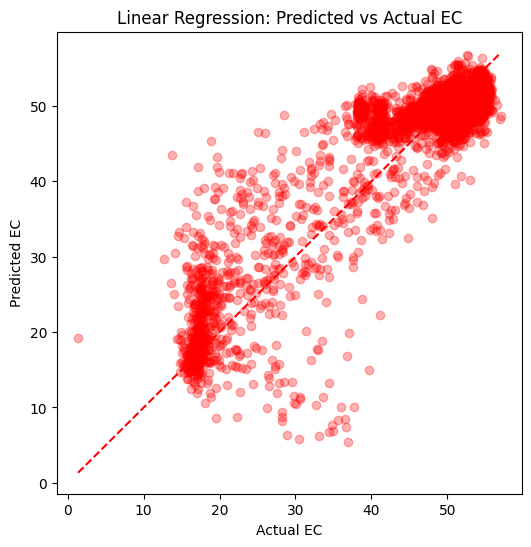

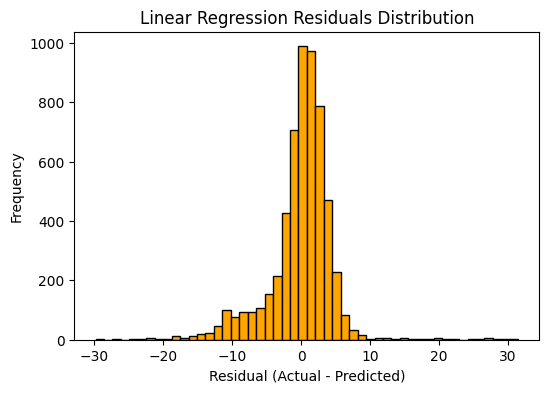

In [45]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred_lr, alpha=0.3, color="red")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual EC")
plt.ylabel("Predicted EC")
plt.title("Linear Regression: Predicted vs Actual EC")
plt.show()

residuals_lr = y_test - y_test_pred_lr
plt.figure(figsize=(6,4))
plt.hist(residuals_lr, bins=50, color="orange", edgecolor="black")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Linear Regression Residuals Distribution")
plt.show()

## Polynomial Linear Regression

### Train, Predict, and Evaluate

In [46]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)


poly_lr = LinearRegression()
poly_lr.fit(X_train_poly, y_train)

y_train_pred_poly = poly_lr.predict(X_train_poly)
y_test_pred_poly = poly_lr.predict(X_test_poly)

print("Polynomial Linear Regression Performance:")
evaluate(y_train, y_train_pred_poly, "Train")
evaluate(y_test, y_test_pred_poly, "Test")

Polynomial Linear Regression Performance:
Train RMSE: 1.617
Train R²: 0.976 

Test RMSE: 1.629
Test R²: 0.976 



###  Visualization

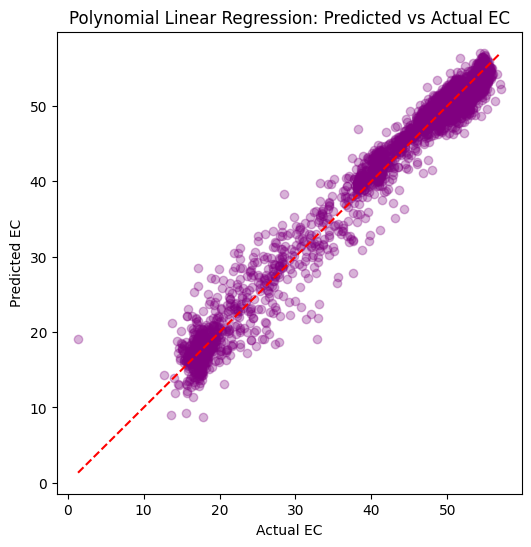

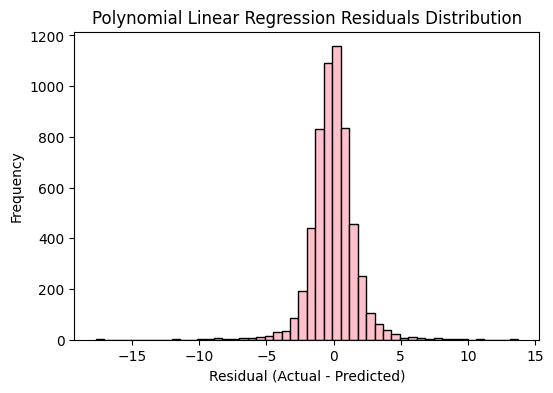

In [47]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred_poly, alpha=0.3, color="purple")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual EC")
plt.ylabel("Predicted EC")
plt.title("Polynomial Linear Regression: Predicted vs Actual EC")
plt.show()

residuals_poly = y_test - y_test_pred_poly
plt.figure(figsize=(6,4))
plt.hist(residuals_poly, bins=50, color="pink", edgecolor="black")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Polynomial Linear Regression Residuals Distribution")
plt.show()


## Random Forest

### Train, Predict, and Evaluaion

In [48]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    min_samples_split=5,
    random_state=42,
)

rf_model.fit(X_train_scaled, y_train)
y_train_pred = rf_model.predict(X_train_scaled)
y_test_pred = rf_model.predict(X_test_scaled)

evaluate(y_train, y_train_pred, "Train")
evaluate(y_test, y_test_pred, "Test")


Train RMSE: 0.494
Train R²: 0.998 

Test RMSE: 1.164
Test R²: 0.988 



### Visualization

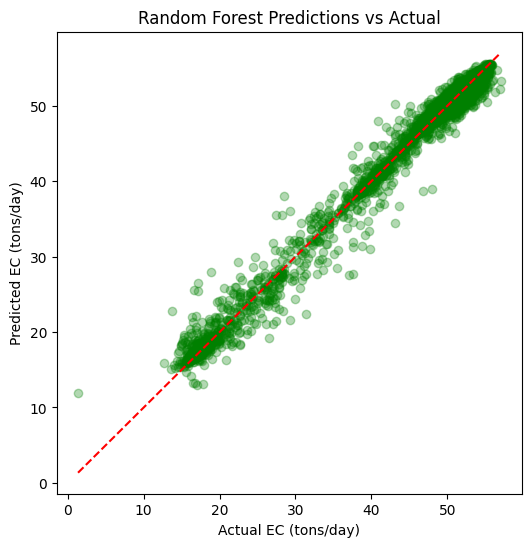

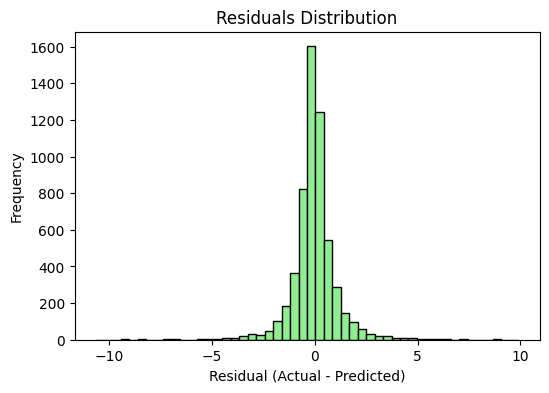

In [49]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred, alpha=0.3, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual EC (tons/day)")
plt.ylabel("Predicted EC (tons/day)")
plt.title("Random Forest Predictions vs Actual")
plt.show()

residuals = y_test - y_test_pred
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=50, color="lightgreen", edgecolor="black")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Residuals Distribution")
plt.show()


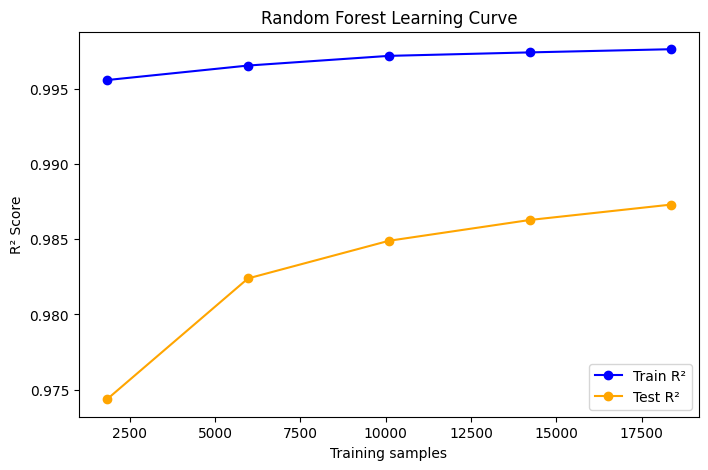

In [50]:
train_sizes, train_scores, test_scores = learning_curve(
    rf_model, X_train_scaled, y_train, cv=5,
    scoring="r2", n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, "o-", color="blue", label="Train R²")
plt.plot(train_sizes, test_mean, "o-", color="orange", label="Test R²")
plt.xlabel("Training samples")
plt.ylabel("R² Score")
plt.title("Random Forest Learning Curve")
plt.legend()
plt.show()
